# Model Optimization with Gradient Descent

Using a very simple model of diffusivity, we will show how we can use gradient descent to optimize the model parameters.

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/08-NeuralNetworks"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# for an interactive visualization
from ipywidgets import interact, IntSlider, FloatSlider

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## First, let's generate some data

We will use the model of diffusivity that we explored in a previous lecture.
The model is simple: we generate data for an Arrhenius behavior for which we know the parameters.
We inject noise to the data to make it interesting.
Then, we create a model that tries to "learn" these parameters.

In [3]:
# These are the ground-truth quantities that we will use to generate the data
D0 = 2.5e-5
Ea = 200e3  # kJ/mol
R = 8.314   # J/mol.K
N = 12

# the random seed makes it reproducible
np.random.seed(23)

# and here is the Arrhenius behavior
def model(T, D0, Ea):
    return D0 * np.exp(-Ea / (R * T))

T = np.linspace(600, 1000, N)
noise = (1 - 0.03 * np.random.randn(N))

# we inject noise in the activation energy
D = model(T, D0, Ea * noise)

# for machine learning purposes, the temperature is our input (X)
# and the diffusivity is what we want to predict (y)
X = T
y = D

The data visualization is straightforward:

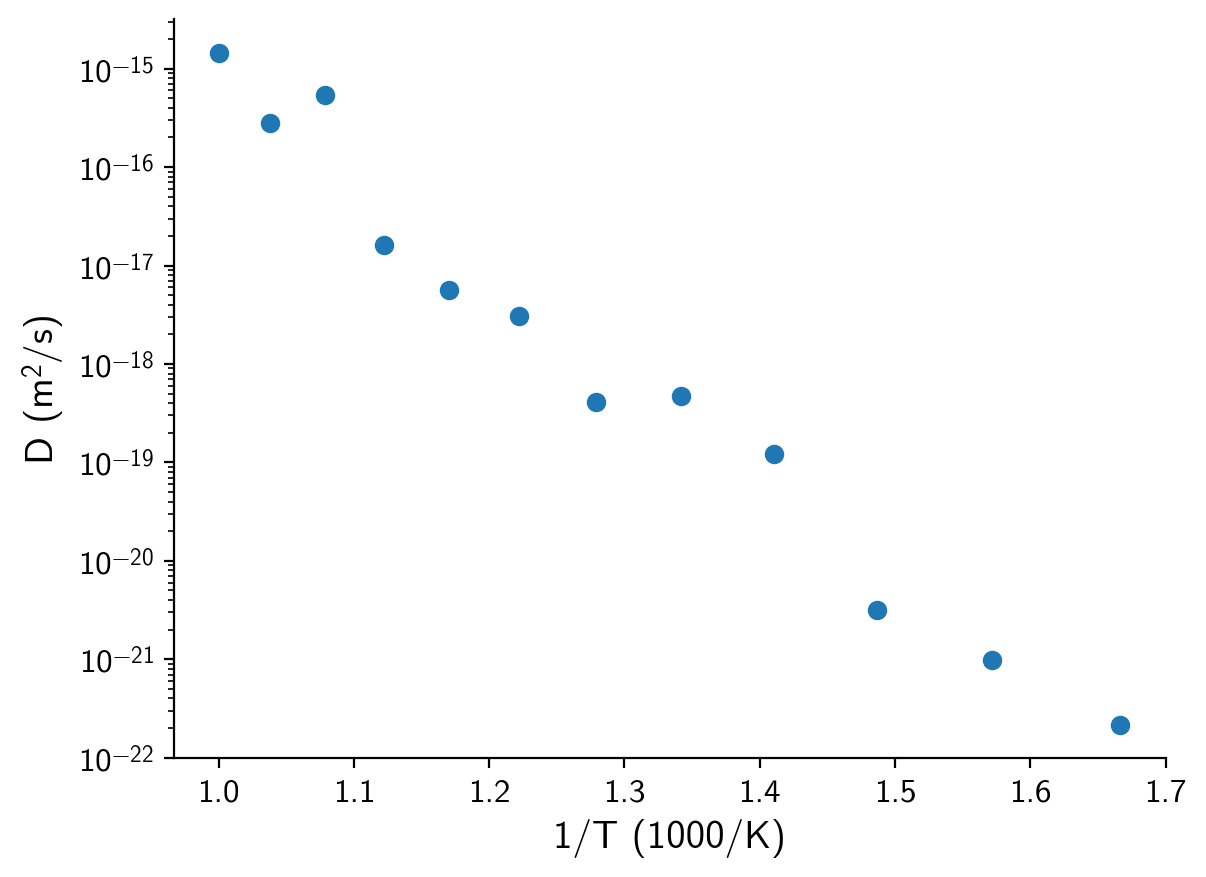

In [4]:
fig, ax = plt.subplots()

ax.scatter(1000 / T, D)

ax.set_xlabel("1/T (1000/K)")
ax.set_ylabel("D (m$^2$/s)")

ax.set_yscale("log")

plt.show()

## Learning the parameters

Now let's try to optimize a model that predicts $E_a$ and $D_0$.

First, we can define a loss function:

In [5]:
def loss(model_fn, X, y):
    y_pred = model_fn(X)
    return np.mean(np.linalg.norm(np.log(y) - np.log(y_pred)) ** 2)

In [6]:
D0_grid = np.logspace(-10, 0, 100)
Ea_grid = np.linspace(20e3, 500e3, 100)
dd, ee = np.meshgrid(D0_grid, Ea_grid)
grid = np.column_stack([dd.ravel(), ee.ravel()])

Over this grid search, we can compute the loss, which represents how wrong is our model based on the noisy observations.

In [7]:
losses = np.array([
    loss(lambda t: model(t, d, e), T, D)
    for d, e in grid
]).reshape(dd.shape)

print(losses.min())

7.965247033244268


The result above shows that the minimum value is never achieved.
This is because we are using a linear model to noisy data, so the loss never reaches zero.

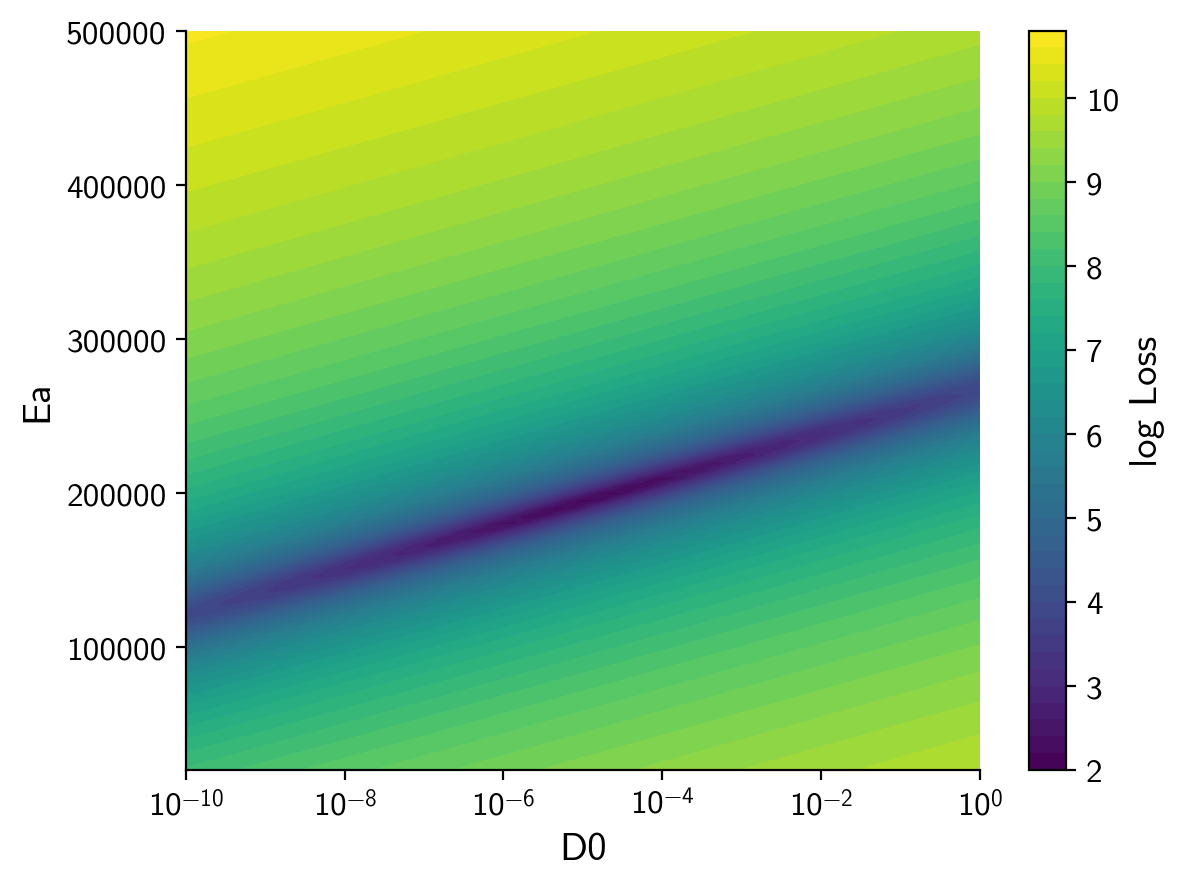

In [8]:
fig, ax = plt.subplots()

cf = ax.contourf(
    dd, ee, np.log(losses), levels=50
)

cbar = fig.colorbar(cf)
cbar.set_label("log Loss")

ax.set_xscale("log")

ax.set_xlabel("D0")
ax.set_ylabel("Ea")

plt.show()

## Performing the parameter optimization with gradient descent

The hardest part of this example is the need to manually define the gradients.
Our loss is defined as the MSE loss,

$$
\mathcal{L} = \frac{1}{N} \sum_i r_i^2,
$$

where $r_i$ are the residuals for the observation $(T_i, D_i)$, given by 

$$
r_i = D_i - \mathrm{model}(T_i | D_0^{(m)}, E_a^{(m)}).
$$

In this equation, $D_0^{(m)}, E_a^{(m)}$ are the parameters of the model.

Given that the equation of the model is known, we can write the gradients analytically (with a log loss):

$$
r_i = \log D_i - \log D_0^{(m)} + \frac{E_a^{(m)}}{R T_i}
$$

Therefore, one can compute the gradient of the loss numerically:

$$ 
\frac{\partial \mathcal{L}}{\partial D_0^{(m)}} = -\frac{2}{N D_0^{(m)}} \sum_i r_i.
$$

Similarly for $E_a$:

$$ 
\frac{\partial \mathcal{L}}{\partial E_a^{(m)}} = \frac{2}{N} \frac{1}{RT} \sum_i r_i.
$$

In [9]:
def gradients(D0, Ea, T, Y):
    """
    Compute the partial derivatives of the loss wrt D0 and Ea.
    Loss = mean(e_i^2), where
        r_i = log(Y_i) - [log(D0) - (Ea / (R * T_i))]
            = log(Y_i) - log(D0) + Ea/(R * T_i)
    """
    N = len(T)
    # Residuals in the log-domain
    r = np.log(Y) - (np.log(D0) - Ea/(R*T))  # shape (N,)

    # dL/dD0 = 2/N * sum(e_i * de_i/dD0) = -2/(N*D0) * sum(e_i)
    dLdD0 = -2.0/(N*D0) * np.sum(r)

    # dL/dEa = 2/N * sum(e_i * de_i/dEa), where de_i/dEa = 1/(R*T_i)
    dLdEa = (2.0/N) * np.sum(r/(R*T))

    return dLdD0, dLdEa

Finally, we can get a guess starting point for $D_0$ and $E_a$ and start optimizing it.

In [10]:
# Hyperparameters
lr_D0 = 1e-14
lr_Ea = 1e6
n_iterations = 150

# Initial guesses for parameters
D0_guess = 5e-8
Ea_guess = 450e3

# Store the trajectory of (D0, Ea)
params_trajectory = [(D0_guess, Ea_guess)]

# Gradient descent loop
for _ in range(n_iterations):
    dD0, dEa = gradients(D0_guess, Ea_guess, X, y)
    D0_guess = D0_guess - lr_D0 * dD0
    Ea_guess = Ea_guess - lr_Ea * dEa
    params_trajectory.append((D0_guess, Ea_guess))

## Visualizing the results

In [11]:
def plot_iteration(iteration):
    """
    For each iteration, show:
      - The predicted function vs. the noisy data.
      - The contour of the loss landscape, plus the trajectory of (D0, Ea).
    """
    # Current parameters
    D0_i, Ea_i = params_trajectory[iteration]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    ax = axs[0]

    # --- Left subplot: Data vs Model ---
    ax.plot(1000 / X, D, 'ro', label='Noisy data')
    ax.plot(1000 / X, model(X, D0_i, Ea_i), 'b-', label='Model')
    ax.set_xlabel('T (K)')
    ax.set_ylabel('D(T)')
    ax.set_yscale("log")
    ax.legend()
    ax.set_title(f'Iteration {iteration}\n'
                      f'D0 = {D0_i:.2e} m^2/s,  Ea = {Ea_i / 1000:.1f} kJ/mol')

    # --- Right subplot: Loss landscape ---
    ax = axs[1]
    cf = ax.contourf(
        dd, ee, np.log(losses), levels=50
    )
    fig.colorbar(cf, ax=ax, label='log Loss')
    ax.set_xscale('log')
    ax.set_xlabel('D0')
    ax.set_ylabel('Ea')

    # Overlay the trajectory
    traj = np.array(params_trajectory[:iteration+1])
    ax.plot(traj[:, 0], traj[:, 1], 'w-o', label='Trajectory')
    ax.plot(D0_i, Ea_i, 'rx', ms=8, label='Current')
    ax.legend(loc='upper right')
    ax.set_title('Loss landscape')

    plt.tight_layout()
    plt.show()
    
interact(plot_iteration, iteration=IntSlider(min=0, max=n_iterations, step=1, value=0))

interactive(children=(IntSlider(value=0, description='iteration', max=150), Output()), _dom_classes=('widget-i…

<function __main__.plot_iteration(iteration)>

Observe how the final values are reasonably close to the true values:

```
D0 = 2.5e-5
Ea = 200e3
```